shape: (4, 5)
┌──────────┬──────────────┬─────────────────────┬─────────────┬─────────────────┐
│ product  ┆ total_orders ┆ total_quantity_sold ┆ total_sales ┆ avg_order_value │
│ ---      ┆ ---          ┆ ---                 ┆ ---         ┆ ---             │
│ str      ┆ i64          ┆ i64                 ┆ f64         ┆ f64             │
╞══════════╪══════════════╪═════════════════════╪═════════════╪═════════════════╡
│ Monitor  ┆ 1            ┆ 1                   ┆ 200.0       ┆ 200.0           │
│ Laptop   ┆ 1            ┆ 1                   ┆ 1000.0      ┆ 1000.0          │
│ Keyboard ┆ 1            ┆ 1                   ┆ 45.0        ┆ 45.0            │
│ Mouse    ┆ 1            ┆ 2                   ┆ 51.0        ┆ 51.0            │
└──────────┴──────────────┴─────────────────────┴─────────────┴─────────────────┘


/tmp/ipykernel_2678/1287162269.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pandas, x="product", y="total_sales", palette="viridis")


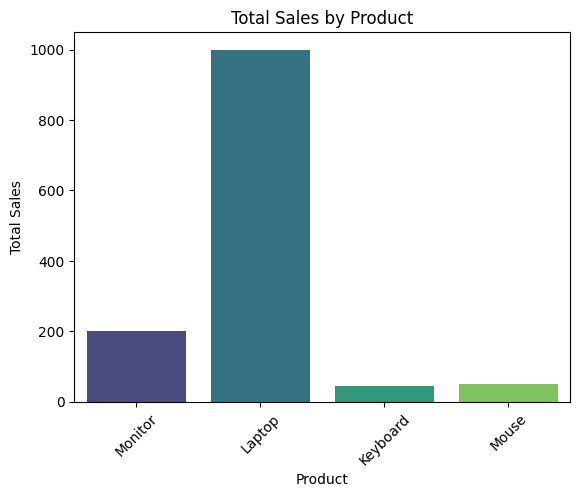

In [1]:
# Query Dremio using Arrow Flight
from dremio_simple_query.connect import get_token, DremioConnection
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Dremio login details
login_endpoint = "http://dremio:9047/apiv2/login"
payload = {
    "userName": "dremio",  # Dremio username
    "password": "dremio123"  # Dremio password
}# Get the token
token = get_token(uri=login_endpoint, payload=payload)# Dremio Arrow Flight endpoint (no SSL for local setup)
arrow_endpoint = "grpc://dremio:32010"# Create the connection
dremio = DremioConnection(token, arrow_endpoint)

# Query the Gold dataset
query = "SELECT * FROM nessie.sales.sales_data_gold;"
df = dremio.toPolars(query)# Display the Polars DataFrame
print(df)

# Convert the Polars DataFrame to a Pandas DataFrame for Seaborn visualization
df_pandas = df.to_pandas()# Create a bar plot of total sales by product
sns.barplot(data=df_pandas, x="product", y="total_sales", palette="viridis")
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()